# EU Logistics Performance and Freight Modal Analysis
## Comparing World Bank LPI Scores Against Eurostat Freight Data (2022)

**Data sources:**
- World Bank Logistics Performance Index (LPI) \[2022\]
- Eurostat Road Freight Transport Statistics (`road_go_ta_tott`) \[2018, 2022\]
- Eurostat Inland Freight Modal Split (`tran_hv_frmod`) \[2022\]

**Analytical question:**
How do European countries compare across logistics quality and inland freight 
modal mix, and where do high logistics scores correlate with greater rail usage?

**Note on scope:**
Modal split data covers inland modes only (road, rail, inland waterway). 
Maritime transport is excluded as it dominates EU freight by volume (67% of 
total tonne-kilometres) and skews cross-country comparison for landlocked 
and coastal nations alike.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pipeline import run_pipeline

import os
os.makedirs('charts', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:,.2f}'.format)

# Run pipeline and load combined dataset
df = run_pipeline(join_year=2022)

print(f'\nDataset shape: {df.shape}')
df.head()

2026-04-22 23:05:54,602 | INFO | ==================================================
2026-04-22 23:05:54,604 | INFO | Starting EU Logistics Pipeline
2026-04-22 23:05:54,605 | INFO | Join year: 2022
2026-04-22 23:05:54,607 | INFO | ==================================================
2026-04-22 23:05:54,608 | INFO | Fetching World Bank LPI data...
2026-04-22 23:05:56,318 | INFO |   Page 1/3 fetched (500 records)
2026-04-22 23:05:57,541 | INFO |   Page 2/3 fetched (500 records)
2026-04-22 23:05:58,729 | INFO |   Page 3/3 fetched (330 records)
2026-04-22 23:05:58,740 | INFO | World Bank LPI: 385 valid records across 208 countries
2026-04-22 23:05:58,750 | INFO | Fetching Eurostat road freight data...
2026-04-22 23:06:00,560 | INFO | Eurostat freight: 59 valid records across 30 countries
2026-04-22 23:06:00,563 | INFO | Fetching Eurostat modal split data...
2026-04-22 23:06:02,455 | INFO | Modal split: 29 country-year records across 29 countries
2026-04-22 23:06:02,460 | INFO | Joining datase


PIPELINE SUMMARY REPORT
LPI vs Road Freight and Modal Split — 2022

Countries in combined dataset: 27
Average LPI score: 3.67
Average freight volume: 72,409M TKM

Top 5 countries by LPI score:
country_name  lpi_score  tkm_2022  road_share_pct  rail_share_pct
     Finland       4.20     30590           77.00           22.50
     Denmark       4.10     15162           90.40            9.60
     Germany       4.10    303948           72.30           21.00
 Switzerland       4.10     12988           66.30           33.60
 Netherlands       4.10     65466           52.20            6.60

Top 5 countries by freight volume:
country_name  lpi_score  tkm_2022  road_share_pct  rail_share_pct
      Poland       3.60    385089           76.80           23.20
     Germany       4.10    303948           72.30           21.00
       Spain       3.90    266724           95.60            4.40
      France       3.90    173353           87.40           10.60
       Italy       3.70    151100           

,iso3,country_name,lpi_score,tkm_2022,tkm_2018,tkm_change_pct,road_share_pct,rail_share_pct,iww_share_pct
8,FIN,Finland,4.20,30590,28345,7.92,77.00,22.50,0.50
6,DNK,Denmark,4.10,15162,14998,1.09,90.40,9.60,0.00
10,DEU,Germany,4.10,303948,316772,-4.05,72.30,21.00,6.70
28,CHE,Switzerland,4.10,12988,12500,3.90,66.30,33.60,0.10
19,NLD,Netherlands,4.10,65466,68876,-4.95,52.20,6.60,41.10


## Dataset Overview

27 European countries with complete data across all three sources.

| Metric | Value |
|---|---|
| Countries | 27 |
| Average LPI score | 3.67 / 5.0 |
| Average road freight volume (2022) | 72,409M TKM |
| LPI range | 3.3 (Slovenia, Slovakia) to 4.2 (Finland) |
| Road modal share range | 46.8% (Latvia) to 99.3% (Ireland) |
| Rail modal share range | 0.7% (Ireland) to 53.2% (Latvia) |

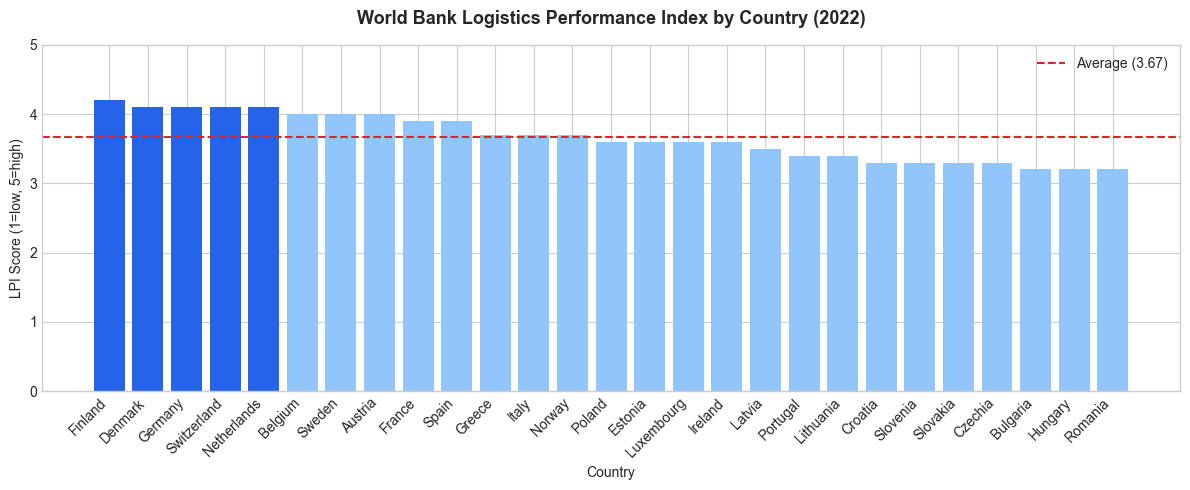

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#2563eb' if c in ['Finland', 'Germany', 'Denmark', 'Switzerland', 'Netherlands'] 
          else '#93c5fd' for c in df.sort_values('lpi_score', ascending=False)['country_name']]

bars = ax.bar(
    df.sort_values('lpi_score', ascending=False)['country_name'],
    df.sort_values('lpi_score', ascending=False)['lpi_score'],
    color=colors
)

ax.axhline(y=df['lpi_score'].mean(), color='#dc2626', linewidth=1.5, 
           linestyle='--', label=f'Average ({df["lpi_score"].mean():.2f})')

ax.set_title('World Bank Logistics Performance Index by Country (2022)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('LPI Score (1=low, 5=high)')
ax.set_ylim(0, 5)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/chart1_lpi_scores.png', dpi=150)
plt.show()

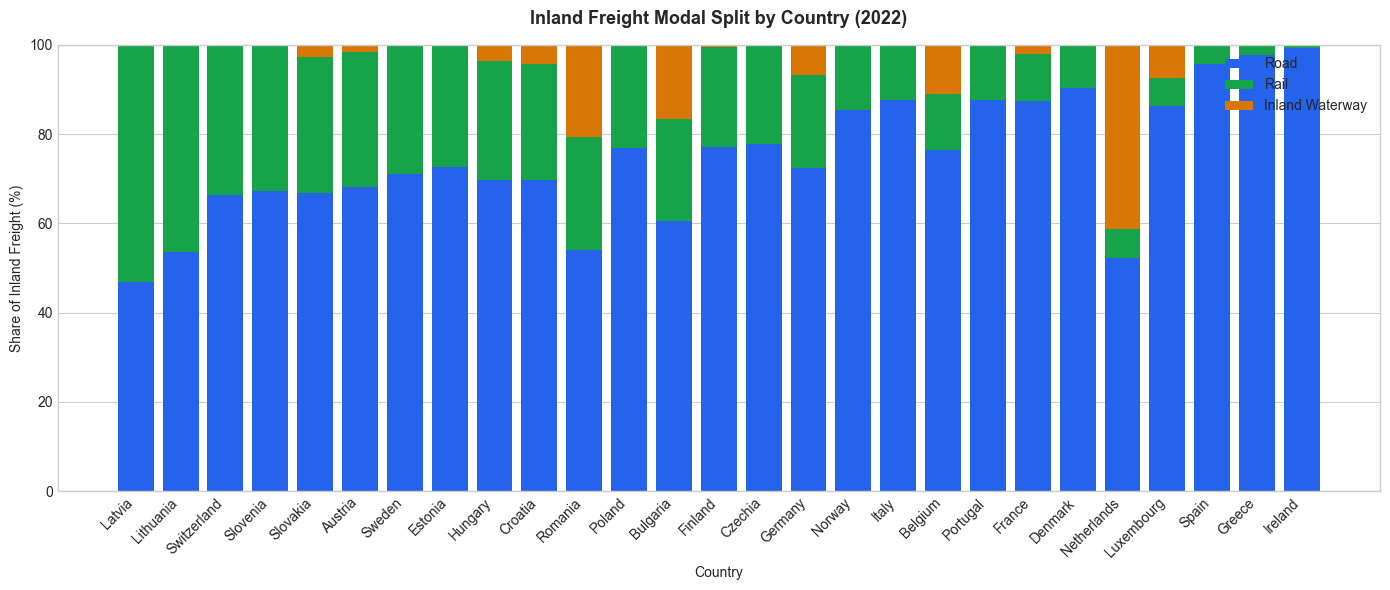

In [3]:
# Sort by rail share descending for visual clarity
df_modal = df.sort_values('rail_share_pct', ascending=False).copy()

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df_modal['country_name'], df_modal['road_share_pct'], 
       label='Road', color='#2563eb')
ax.bar(df_modal['country_name'], df_modal['rail_share_pct'],
       bottom=df_modal['road_share_pct'],
       label='Rail', color='#16a34a')
ax.bar(df_modal['country_name'], df_modal['iww_share_pct'],
       bottom=df_modal['road_share_pct'] + df_modal['rail_share_pct'],
       label='Inland Waterway', color='#d97706')

ax.set_title('Inland Freight Modal Split by Country (2022)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Country')
ax.set_ylabel('Share of Inland Freight (%)')
ax.set_ylim(0, 100)
ax.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/chart2_modal_split.png', dpi=150)
plt.show()

## Finding 1: Modal Mix Varies Dramatically Across Europe

The inland freight modal split reveals two distinct groups of countries:

**Rail-balanced countries (eastern Europe and Alpine):**
- Latvia (53.2% rail) and Lithuania (46.4% rail) reflect Soviet-era 
  rail infrastructure still in active use
- Switzerland (33.6% rail) and Slovenia (32.7% rail) reflect Alpine 
  geography favouring rail for cross-border freight
- Austria and Slovakia both above 30% rail

**Road-dominant countries (western and southern Europe):**
- Ireland (99.3% road) and Greece (97.7% road) are almost entirely road dependent
- Spain (95.6%), Denmark (90.4%), and Portugal (87.7%) follow the same pattern
- Geographic isolation (Ireland) and limited rail freight investment explain much of this

**The Netherlands exception:**
- 41.1% inland waterway share — by far the highest in the dataset
- Reflects the Rhine corridor and Rotterdam port hinterland connections
- Road share of 52.2% is the lowest of any country alongside Latvia

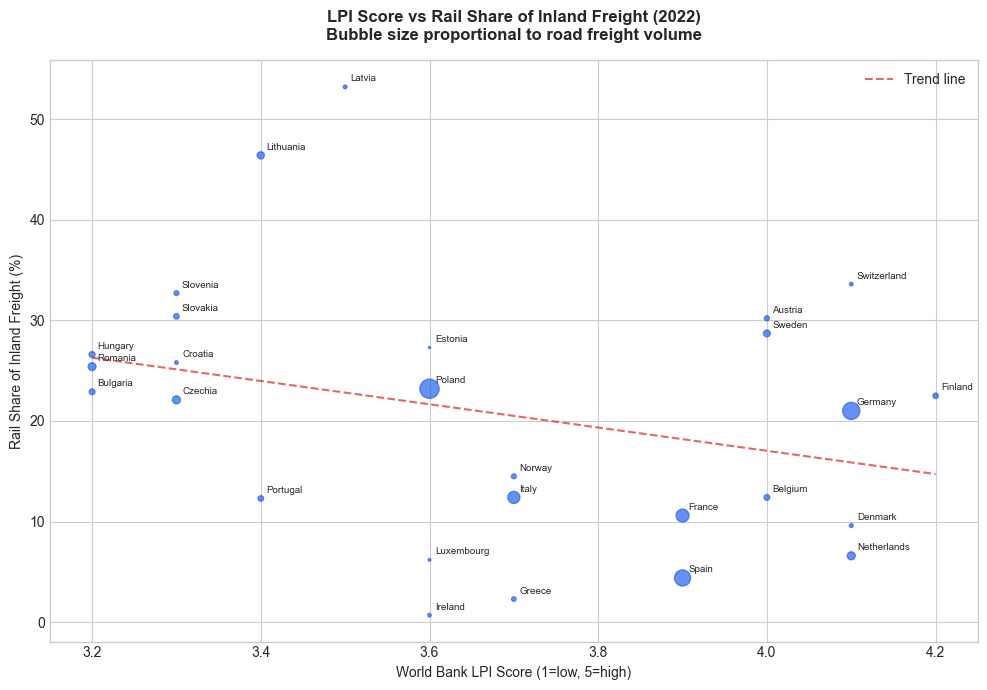


Correlation between LPI score and rail share: -0.298


In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    df['lpi_score'],
    df['rail_share_pct'],
    s=df['tkm_2022'] / 2000,  # size proportional to freight volume
    alpha=0.7,
    color='#2563eb'
)

# Label each country
for _, row in df.iterrows():
    ax.annotate(
        row['country_name'],
        xy=(row['lpi_score'], row['rail_share_pct']),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=7
    )

# Add trend line
import numpy as np
z = np.polyfit(df['lpi_score'], df['rail_share_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['lpi_score'].min(), df['lpi_score'].max(), 100)
ax.plot(x_line, p(x_line), color='#dc2626', linewidth=1.5, 
        linestyle='--', alpha=0.7, label='Trend line')

ax.set_title('LPI Score vs Rail Share of Inland Freight (2022)\nBubble size proportional to road freight volume',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('World Bank LPI Score (1=low, 5=high)')
ax.set_ylabel('Rail Share of Inland Freight (%)')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart3_lpi_vs_rail.png', dpi=150)
plt.show()

# Calculate correlation
corr = df['lpi_score'].corr(df['rail_share_pct'])
print(f'\nCorrelation between LPI score and rail share: {corr:.3f}')

## Finding 2: Higher Logistics Quality Does Not Predict Greater Rail Usage

The correlation between LPI score and rail share of inland freight is -0.298 — 
weak and negative. Countries with higher logistics performance scores are 
marginally less likely to use rail, not more.

This finding challenges an intuitive assumption and reveals a more nuanced picture:

**Rail-heavy countries tend to score lower on LPI:**
- Latvia (53.2% rail, LPI 3.5) and Lithuania (46.4% rail, LPI 3.4) rely heavily 
  on Soviet-era rail infrastructure. High rail usage reflects legacy infrastructure 
  rather than a deliberate logistics quality investment.
- Slovenia and Slovakia similarly — geographic and historical factors drive modal 
  mix more than logistics system quality.

**High-LPI countries achieve quality through road and port excellence:**
- Finland (LPI 4.2), Germany (LPI 4.1), and Denmark (LPI 4.1) have invested 
  heavily in road logistics efficiency, customs technology, and port connectivity.
- Their high LPI scores reflect the quality of these systems, not modal diversity.

**The Netherlands is the clearest outlier:**
- LPI 4.1, only 6.6% rail — but 41.1% inland waterway.
- Modal balance is achieved through the Rhine corridor and Rotterdam hinterland 
  connections, not rail. This is a structurally distinct logistics model.

**Conclusion:** Modal mix is driven primarily by geography, historical 
infrastructure investment, and industrial structure — not by logistics 
system quality as measured by LPI. The two metrics are largely independent.

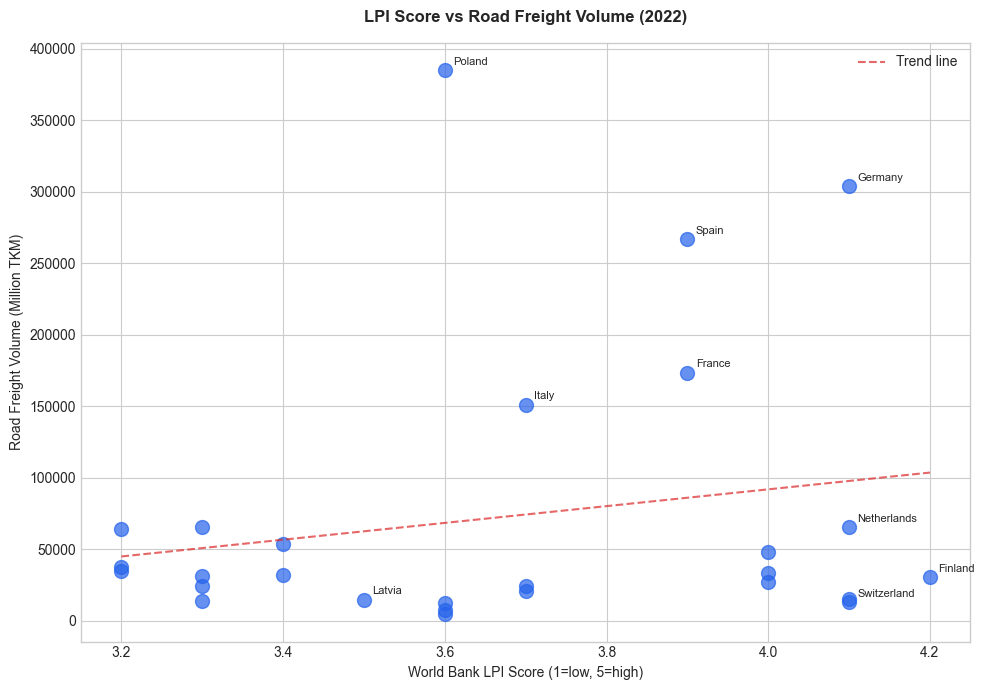

Correlation between LPI score and freight volume: 0.198


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    df['lpi_score'],
    df['tkm_2022'],
    s=100,
    alpha=0.7,
    color='#2563eb'
)

# Label selected countries only to avoid crowding
label_countries = ['Poland', 'Germany', 'Spain', 'France', 'Italy', 
                   'Finland', 'Netherlands', 'Latvia', 'Switzerland']
for _, row in df[df['country_name'].isin(label_countries)].iterrows():
    ax.annotate(
        row['country_name'],
        xy=(row['lpi_score'], row['tkm_2022']),
        xytext=(6, 4),
        textcoords='offset points',
        fontsize=8
    )

# Trend line
z = np.polyfit(df['lpi_score'], df['tkm_2022'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['lpi_score'].min(), df['lpi_score'].max(), 100)
ax.plot(x_line, p(x_line), color='#dc2626', linewidth=1.5,
        linestyle='--', alpha=0.7, label='Trend line')

ax.set_title('LPI Score vs Road Freight Volume (2022)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('World Bank LPI Score (1=low, 5=high)')
ax.set_ylabel('Road Freight Volume (Million TKM)')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart4_lpi_vs_volume.png', dpi=150)
plt.show()

corr2 = df['lpi_score'].corr(df['tkm_2022'])
print(f'Correlation between LPI score and freight volume: {corr2:.3f}')

In [ ]:
## Finding 3: Freight Volume and Logistics Quality Are Largely Independent

The correlation between LPI score and road freight volume is 0.198 — 
effectively no relationship. Country size, geographic position, and 
industrial structure explain freight volume far better than logistics 
quality scores.

Two countries illustrate this most clearly:

**Poland (LPI 3.6, 385,089M TKM):**
The highest freight volume in the dataset paired with a mid-table LPI score. 
Poland's dominance reflects scale, cost competitiveness, and geographic 
position as the primary east-west transit corridor — not logistics system 
sophistication.

**Switzerland (LPI 4.1, 12,988M TKM):**
The highest LPI tier paired with one of the lowest freight volumes. 
Switzerland's logistics system is highly efficient and reliable, but its 
small size and landlocked Alpine geography constrain absolute volume.

**Conclusion:**
LPI scores measure the quality and efficiency of logistics systems. 
Freight volume measures economic activity and geographic transit flows. 
These are related but distinct concepts, and treating one as a proxy 
for the other would be analytically misleading.

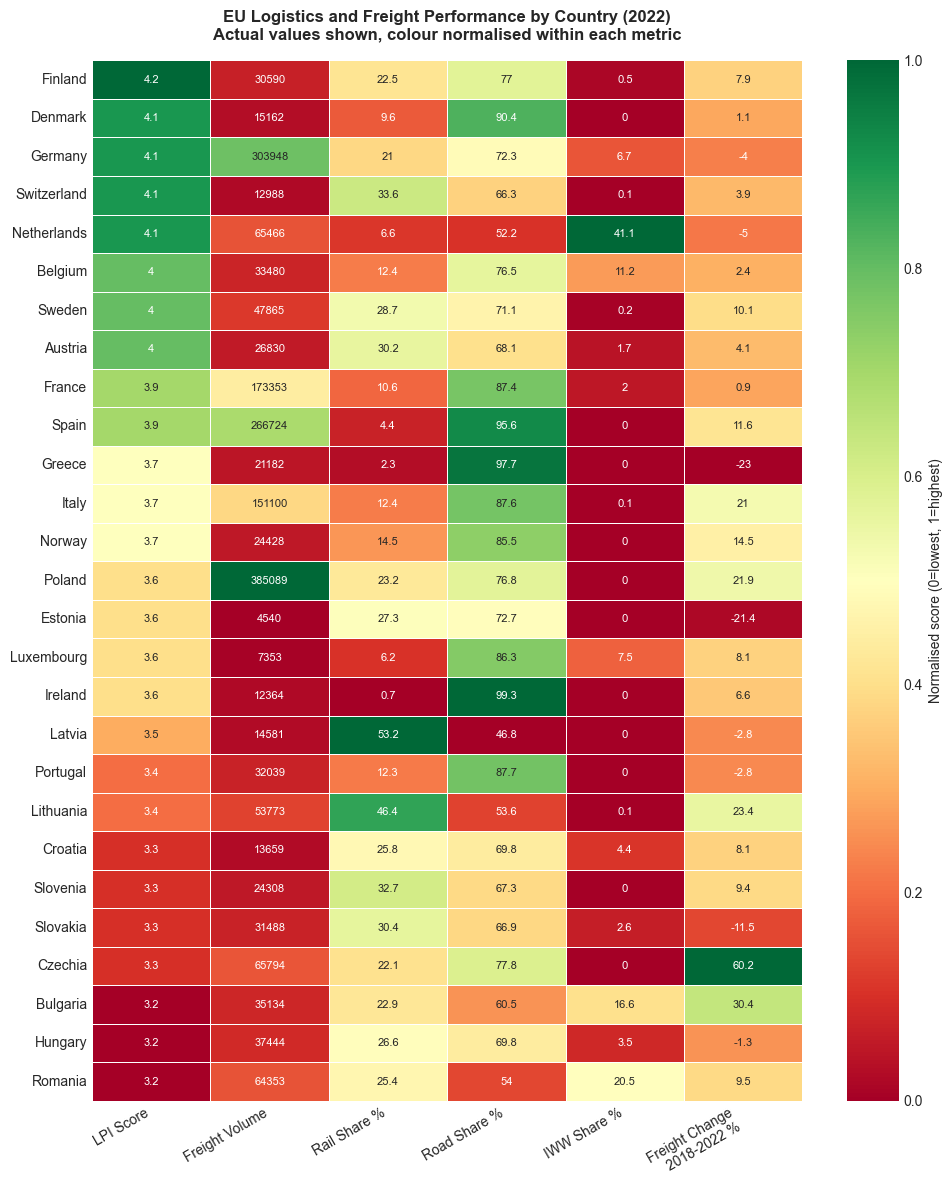

In [6]:
from matplotlib.colors import TwoSlopeNorm

# Select and normalise columns for heatmap
heatmap_cols = {
    'lpi_score': 'LPI Score',
    'tkm_2022': 'Freight Volume',
    'rail_share_pct': 'Rail Share %',
    'road_share_pct': 'Road Share %',
    'iww_share_pct': 'IWW Share %',
    'tkm_change_pct': 'Freight Change\n2018-2022 %'
}

df_heat = df.set_index('country_name')[list(heatmap_cols.keys())].copy()
df_heat.columns = list(heatmap_cols.values())

# Normalise each column to 0-1 for comparison
df_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min())

# Sort by LPI score descending
df_norm = df_norm.sort_values('LPI Score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))

sns.heatmap(
    df_norm,
    ax=ax,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    annot=df_heat.loc[df_norm.index].round(1),
    fmt='g',
    annot_kws={'size': 8},
    cbar_kws={'label': 'Normalised score (0=lowest, 1=highest)'}
)

ax.set_title('EU Logistics and Freight Performance by Country (2022)\nActual values shown, colour normalised within each metric',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/chart5_heatmap.png', dpi=150)
plt.show()

## Summary of Findings

This pipeline combines three data sources — World Bank LPI, Eurostat road 
freight volumes, and Eurostat inland modal split — to produce a cross-country 
view of European logistics performance in 2022.

### Finding 1: Modal Mix Is Driven by Geography and History, Not Logistics Quality
Inland freight modal split varies dramatically across Europe, from Latvia 
(53.2% rail) to Ireland (99.3% road). This variation reflects Soviet-era 
rail infrastructure, Alpine geography, and river corridor access — not 
logistics system quality as measured by LPI.

### Finding 2: Higher LPI Does Not Predict Greater Rail Usage
The correlation between LPI score and rail share is -0.298. High-scoring 
western European countries have invested in road and port logistics 
excellence rather than rail freight capacity. Baltic states use more rail 
due to legacy infrastructure, not logistics sophistication.

### Finding 3: Freight Volume and Logistics Quality Are Largely Independent
The correlation between LPI score and freight volume is 0.198. Poland 
generates the highest freight volume in the dataset at a mid-table LPI 
score of 3.6, while Switzerland and Finland combine top LPI scores with 
modest volumes. Country size, geography, and transit position explain 
freight volume better than logistics quality scores.

### Methodological Note
This analysis is descriptive and cross-sectional. With LPI data available 
for only two years (2018 and 2022), causal claims cannot be supported. 
The findings describe patterns and relationships — not mechanisms.

---
*Pipeline: Python (requests, pandas) | Sources: World Bank API, Eurostat API*  
*Data vintage: LPI 2022, Eurostat freight 2022, Modal split 2022*